# Dimensionality estimator — synthetic demo

Tests all public functions and visualises results on the paper's linear generative model.

**Generative model (Section 4.3)**
$$\Phi = \frac{1}{d} X W + \text{noise}, \quad X \sim \mathcal{N}(0,I_d)^{P\times d},\; W \sim \mathcal{N}(0,I_d)^{d\times Q}$$

As $P, Q \to \infty$ the true participation ratio $\gamma \to d$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dimensionality import (
    participation_ratio,
    participation_ratio_finite,
    sweep_dimensionality,
    plot_sweep,
)

In [2]:
# ── Generative model helpers ───────────────────────────────────────────────

def make_Phi(P, Q, d, sigma=0.0, rng=None):
    """Single-trial activation matrix."""
    if rng is None:
        rng = np.random.default_rng(0)
    X   = rng.standard_normal((P, d))
    W   = rng.standard_normal((d, Q))
    Phi = X @ W / d
    if sigma > 0:
        Phi = Phi + rng.standard_normal((P, Q)) * sigma
    return Phi

def make_two_trials(P, Q, d, sigma, rng=None):
    """Two noisy trials sharing the same X and W."""
    if rng is None:
        rng = np.random.default_rng(0)
    X      = rng.standard_normal((P, d))
    W      = rng.standard_normal((d, Q))
    signal = X @ W / d
    Phi1   = signal + rng.standard_normal((P, Q)) * sigma
    Phi2   = signal + rng.standard_normal((P, Q)) * sigma
    return Phi1, Phi2

# Shared parameters
D_TRUE = 20      # true latent dimensionality
SIGMA  = 0.1     # noise std
print(f'True d = {D_TRUE},  noise σ = {SIGMA}')

True d = 20,  noise σ = 0.1


---
## 1 · Single-call demo — all four estimators

In [3]:
rng = np.random.default_rng(0)

# Moderate size: noticeable bias but correctable
Phi = make_Phi(P=20, Q=20, d=D_TRUE, rng=rng)

result = participation_ratio(Phi, return_all=True)

print(f'True d        = {D_TRUE}')
print(f'γ_naive       = {result["naive"]:.3f}   (no correction)')
print(f'γ_row         = {result["row"]:.3f}   (row bias removed)')
print(f'γ_col         = {result["col"]:.3f}   (col bias removed)')
print(f'γ_both        = {result["both"]:.3f}   (both corrected ← default)')

True d        = 20
γ_naive       = 6.724   (no correction)
γ_row         = 10.328   (row bias removed)
γ_col         = 10.322   (col bias removed)
γ_both        = 21.453   (both corrected ← default)


In [4]:
# return_parts also gives numerator A and denominator B
res_parts = participation_ratio(Phi, return_all=True, return_parts=True)
print('Keys with return_all=True, return_parts=True:')
print(sorted(res_parts.keys()))

Keys with return_all=True, return_parts=True:
['A_both', 'A_col', 'A_naive', 'A_row', 'B_both', 'B_col', 'B_naive', 'B_row', 'both', 'col', 'naive', 'row']


---
## 2 · Two-trial noise correction

In [5]:
rng = np.random.default_rng(7)
Phi1, Phi2 = make_two_trials(P=200, Q=200, d=D_TRUE, sigma=SIGMA, rng=rng)

gamma_single = participation_ratio(Phi1)
gamma_two    = participation_ratio(Phi1, Phi2)

print(f'True d          = {D_TRUE}')
print(f'Single-trial γ  = {gamma_single:.3f}')
print(f'Two-trial γ     = {gamma_two:.3f}   (noise corrected)')

True d          = 20
Single-trial γ  = 28.465
Two-trial γ     = 19.449   (noise corrected)


---
## 3 · Finite estimator

In [6]:
rng  = np.random.default_rng(0)
Phi  = make_Phi(P=30, Q=30, d=D_TRUE, rng=rng)

# Assume the observed matrix is sampled from a larger R×C population
R, C = 200, 200

gamma_inf    = participation_ratio(Phi)                             # infinite estimator
res_finite   = participation_ratio_finite(Phi, R=R, C=C,            # finite estimator
                                          return_naive=True)

print(f'True d                  = {D_TRUE}')
print(f'γ_both (infinite)       = {gamma_inf:.3f}')
print(f'γ_naive (from finite)   = {res_finite["naive"]:.3f}')
print(f'γ_finite                = {res_finite["gamma"]:.3f}')

True d                  = 20
γ_both (infinite)       = 23.581
γ_naive (from finite)   = 8.955
γ_finite                = 19.055


---
## 4 · Sweep over P (varying number of stimuli)

In [7]:
# Build a large reference matrix to subsample from
rng      = np.random.default_rng(0)
PHI_FULL = make_Phi(P=500, Q=200, d=D_TRUE, sigma=0.0, rng=rng)

# Sweep P from 10 to 500, fix Q = 200
result_P = sweep_dimensionality(
    PHI_FULL,
    axis     = 'P',
    n_trials = 30,
)
print('Swept P values:', result_P['values'])

Swept P values: [ 10  14  20  29  41  59  84 121 172 246 350 500]


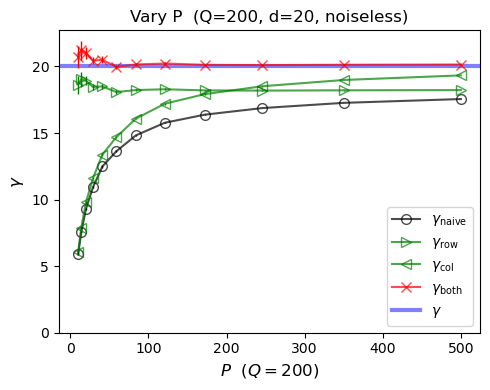

In [8]:
fig, ax = plot_sweep(result_P, true_d=D_TRUE,
                     title=f'Vary P  (Q=200, d={D_TRUE}, noiseless)')
plt.tight_layout()
plt.show()

---
## 5 · Sweep over Q (varying number of neurons)

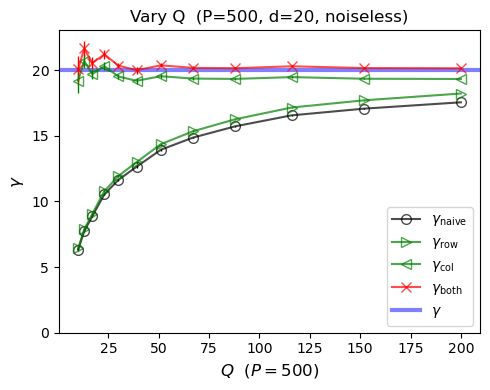

In [9]:
result_Q = sweep_dimensionality(
    PHI_FULL,
    axis     = 'Q',
    n_trials = 30,
)

fig, ax = plot_sweep(result_Q, true_d=D_TRUE,
                     title=f'Vary Q  (P=500, d={D_TRUE}, noiseless)')
plt.tight_layout()
plt.show()

---
## 6 · P-sweep with noise: single-trial vs. two-trial

In [10]:
rng       = np.random.default_rng(1)
Phi1_full, Phi2_full = make_two_trials(
    P=500, Q=200, d=D_TRUE, sigma=SIGMA, rng=rng
)

result_noisy_single = sweep_dimensionality(
    Phi1_full, axis='P', n_trials=30,
)
result_noisy_two = sweep_dimensionality(
    Phi1_full, Phi2=Phi2_full, axis='P', n_trials=30,
)

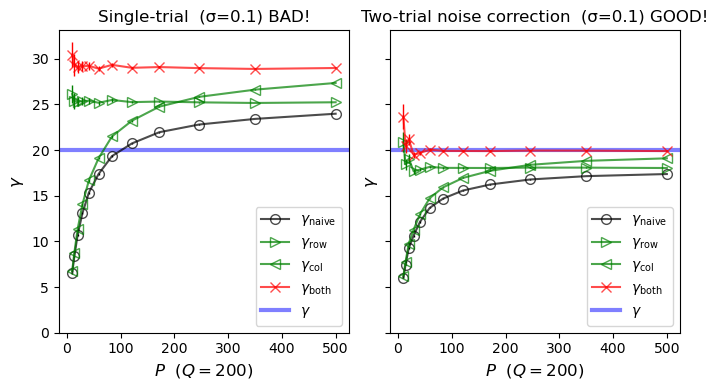

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4), sharey=True)

plot_sweep(result_noisy_single, ax=axes[0], true_d=D_TRUE,
           title=f'Single-trial  (σ={SIGMA}) BAD!')
plot_sweep(result_noisy_two,    ax=axes[1], true_d=D_TRUE,
           title=f'Two-trial noise correction  (σ={SIGMA}) GOOD!')

plt.tight_layout()
plt.show()

---
## 7 · Finite estimator sweep

γ_naive(PHI_POP) = 17.671  ← finite estimator target
γ_both (PHI_POP) = 20.275  ← infinite estimator reference
True d           = 20


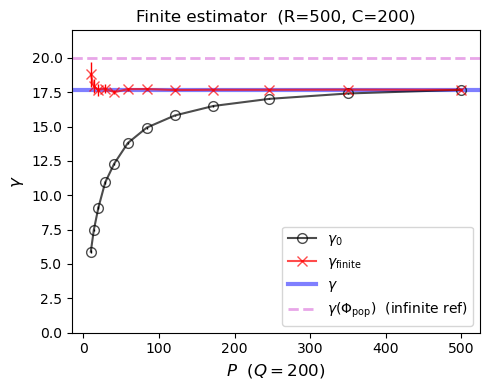

In [12]:
# True underlying matrix: R×C population
R_pop, C_pop = 500, 200
rng           = np.random.default_rng(3)
PHI_POP       = make_Phi(P=R_pop, Q=C_pop, d=D_TRUE, sigma=0.0, rng=rng)

# Reference values computed on the full population matrix
# γ_naive(PHI_POP) is what the finite estimator is targeting when subsampling rows
gamma_pop_naive = participation_ratio(PHI_POP, return_all=True)['naive']
# γ_both(PHI_POP) is the infinite-matrix estimate on PHI_POP (converges to D_TRUE as R,C→∞)
gamma_pop_both  = participation_ratio(PHI_POP)
print(f'γ_naive(PHI_POP) = {gamma_pop_naive:.3f}  ← finite estimator target')
print(f'γ_both (PHI_POP) = {gamma_pop_both:.3f}  ← infinite estimator reference')
print(f'True d           = {D_TRUE}')

# Sweep P using the finite estimator (R and C are the population dimensions)
result_fin = sweep_dimensionality(
    PHI_POP,
    axis      = 'P',
    n_trials  = 30,
    estimator = 'finite',
    R         = R_pop,
    C         = C_pop,
)

fig, ax = plot_sweep(result_fin, true_d=gamma_pop_naive,
                     title=f'Finite estimator  (R={R_pop}, C={C_pop})')
# Faint line: infinite-matrix γ_both on PHI_POP (differs from naive because R,C are finite)
ax.axhline(D_TRUE, color='m', lw=2, alpha=0.35, ls='--',
           label=r'$\gamma(\Phi_{\rm pop})$  (infinite ref)', zorder=-10)
ax.legend(fontsize=10, framealpha=0.8)
ax.set_ylim([0,D_TRUE*1.1])
plt.tight_layout()
plt.show()

---
## 8 · P-sweep and Q-sweep side by side

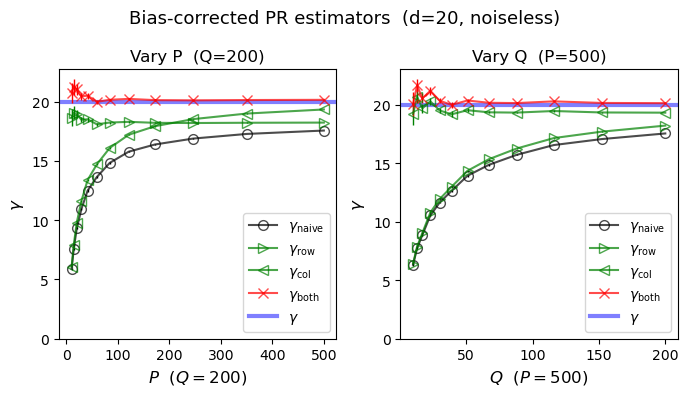

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

plot_sweep(result_P, ax=axes[0], true_d=D_TRUE, title=f'Vary P  (Q=200)')
plot_sweep(result_Q, ax=axes[1], true_d=D_TRUE, title=f'Vary Q  (P=500)')

fig.suptitle(f'Bias-corrected PR estimators  (d={D_TRUE}, noiseless)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9 · `average_before_ratio` option

By default `sweep_dimensionality` computes $\gamma = A/B$ for each subsample and then averages the $\gamma$ values.  Setting `average_before_ratio=True` instead averages $A$ and $B$ separately and returns $\bar{A}/\bar{B}$ under the `*_ratio_of_means` keys.  Both are unbiased for the same quantity; they differ slightly at finite sample sizes.

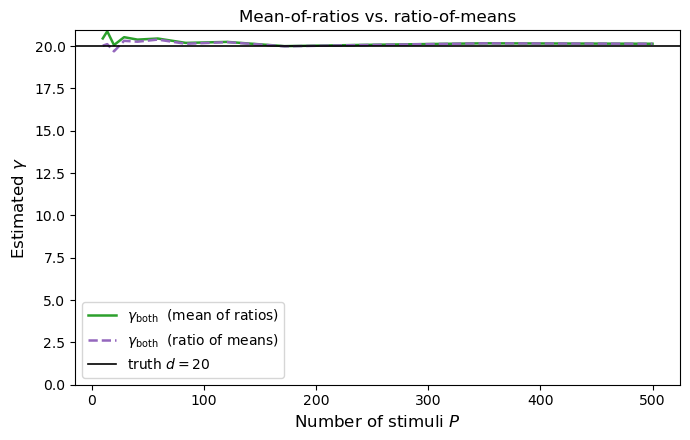

In [14]:
result_abr = sweep_dimensionality(
    PHI_FULL, axis='P', n_trials=30, average_before_ratio=True
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(result_abr['values'], result_abr['both'],
        color='#2CA02C', ls='-',  lw=1.8, label=r'$\gamma_{\rm both}$  (mean of ratios)')
ax.plot(result_abr['values'], result_abr['both_ratio_of_means'],
        color='#9467BD', ls='--', lw=1.8, label=r'$\gamma_{\rm both}$  (ratio of means)')
ax.axhline(D_TRUE, color='black', lw=1.2, label=f'truth $d={D_TRUE}$')
ax.set_xlabel(r'Number of stimuli $P$', fontsize=12)
ax.set_ylabel(r'Estimated $\gamma$', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(bottom=0)
ax.set_title('Mean-of-ratios vs. ratio-of-means', fontsize=12)
plt.tight_layout()
plt.show()